In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
df = pd.read_csv("used_cars.csv")

In [ ]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
df.shape

(4009, 12)

In [ ]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['model_year'], dtype='object')

Categorical Columns:
Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')


In [ ]:
print("Number of rows :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows : 4009
Number of columns : 12


In [ ]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [ ]:
df.describe(include='object')

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [ ]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [ ]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

,Missing Values,Percentage
brand,0,0.000000
model,0,0.000000
model_year,0,0.000000
milage,0,0.000000
fuel_type,170,4.240459
engine,0,0.000000
transmission,0,0.000000
ext_col,0,0.000000
int_col,0,0.000000
accident,113,2.818658


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
brand,57
model,1898
model_year,34
milage,2818
fuel_type,7
engine,1146
transmission,62
ext_col,319
int_col,156
accident,2


In [ ]:
df['brand'].value_counts()

,count
brand,
Ford,386
BMW,375
Mercedes-Benz,315
Chevrolet,292
Porsche,201
Audi,200
Toyota,199
Lexus,163
Jeep,143


In [ ]:
df['fuel_type'].value_counts(dropna=False)

,count
fuel_type,
Gasoline,3309
Hybrid,194
NaN,170
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34
not supported,2


In [ ]:
df['transmission'].value_counts()

,count
transmission,
A/T,1037
8-Speed A/T,406
Transmission w/Dual Shift Mode,398
6-Speed A/T,362
6-Speed M/T,248
...,...
10-Speed Automatic with Overdrive,1
9-Speed Automatic with Auto-Shift,1
SCHEDULED FOR OR IN PRODUCTION,1


In [ ]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,2910
At least 1 accident or damage reported,986
NaN,113


In [ ]:
df['clean_title'].value_counts(dropna=False)

,count
clean_title,
Yes,3413
NaN,596


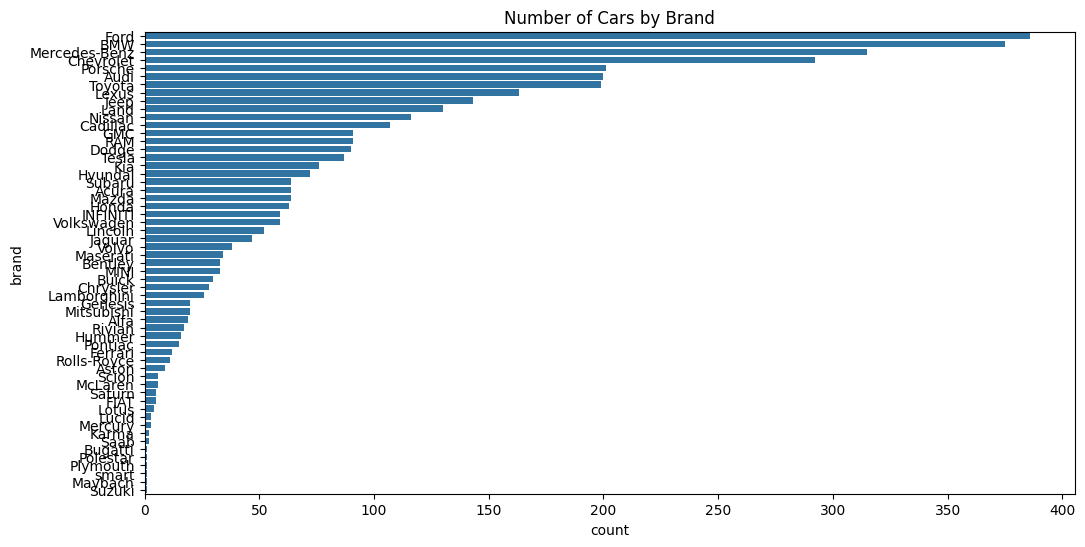

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='brand',
    data=df,
    order=df['brand'].value_counts().index
)

plt.title("Number of Cars by Brand")

plt.show()

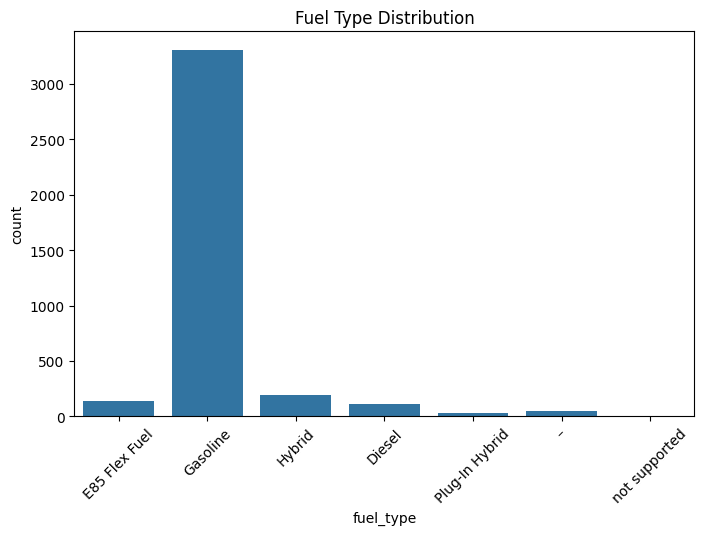

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='fuel_type',
    data=df
)

plt.xticks(rotation=45)

plt.title("Fuel Type Distribution")

plt.show()

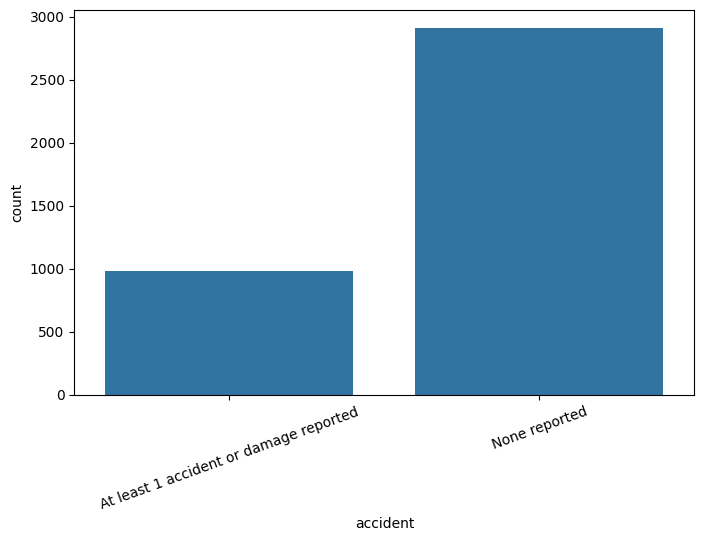

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='accident',
    data=df
)

plt.xticks(rotation=20)

plt.show()

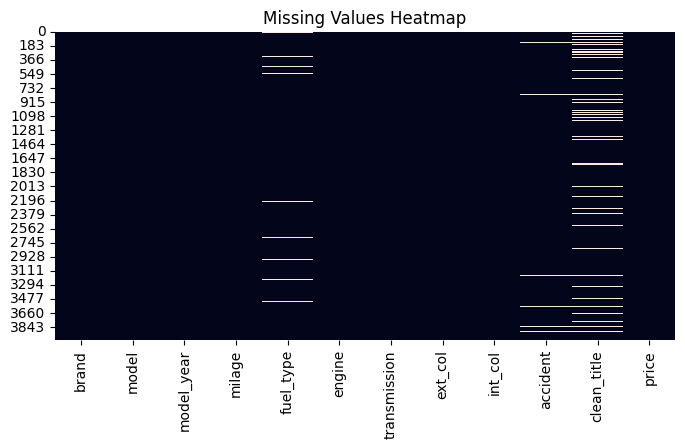

In [ ]:
plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

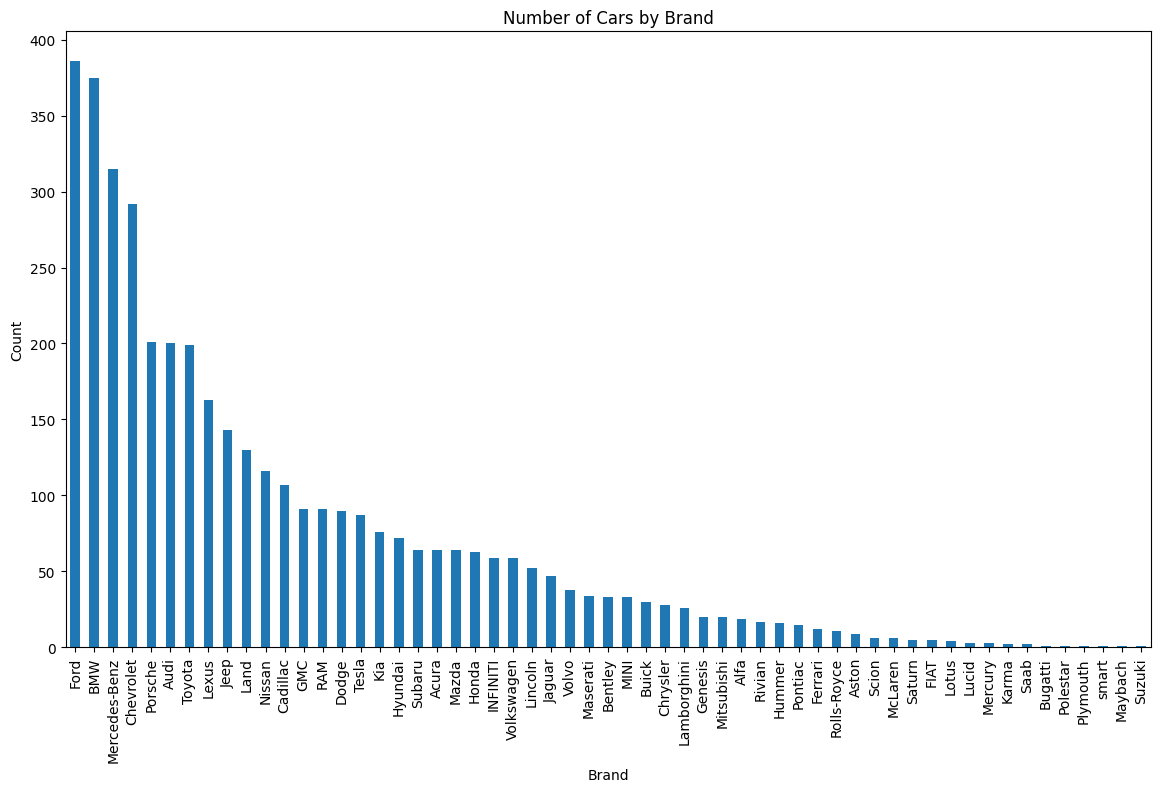

In [ ]:
plt.figure(figsize=(14,8))

df['brand'].value_counts().plot(kind='bar')

plt.title("Number of Cars by Brand")

plt.xlabel("Brand")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

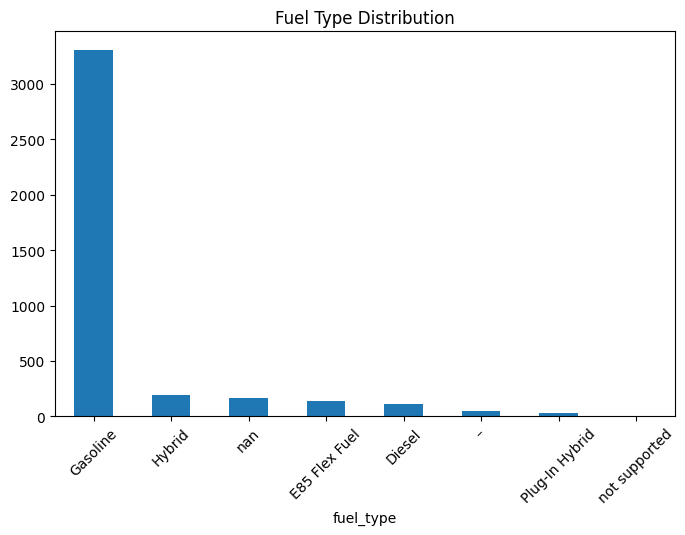

In [28]:
plt.figure(figsize=(8,5))

df['fuel_type'].value_counts(dropna=False).plot(kind='bar')

plt.title("Fuel Type Distribution")

plt.xticks(rotation=45)

plt.show()

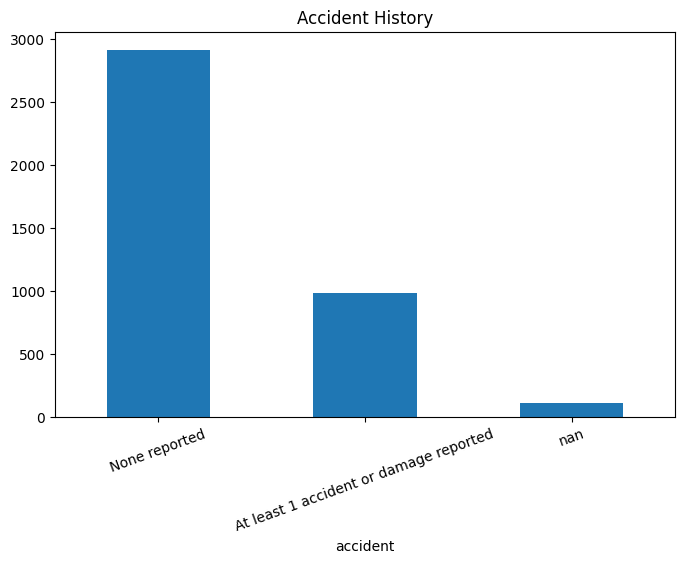

In [29]:
plt.figure(figsize=(8,5))

df['accident'].value_counts(dropna=False).plot(kind='bar')

plt.title("Accident History")

plt.xticks(rotation=20)

plt.show()

In [30]:
df_clean = df.copy()

In [31]:
df_clean.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [32]:
df_clean.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [33]:
df_clean['price'] = (
    df_clean['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

In [34]:
df_clean['price'] = pd.to_numeric(df_clean['price'])

In [35]:
df_clean['price'].head()

,price
0,10300
1,38005
2,54598
3,15500
4,34999


In [36]:
df_clean['price'].dtype

dtype('int64')

In [37]:
df_clean['milage'] = (
    df_clean['milage']
    .str.replace(',', '', regex=False)
    .str.replace(' mi.', '', regex=False)
)

In [38]:
df_clean['milage'] = pd.to_numeric(df_clean['milage'])

In [39]:
df_clean['milage'].head()

,milage
0,51000
1,34742
2,22372
3,88900
4,9835


In [40]:
df_clean['milage'].dtype

dtype('int64')

In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   int64 
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 376.0+ KB


In [42]:
df_clean[['milage', 'price']].describe()

,milage,price
count,4009.000000,4.009000e+03
mean,64717.551010,4.455319e+04
std,52296.599459,7.871064e+04
min,100.000000,2.000000e+03
25%,23044.000000,1.720000e+04
50%,52775.000000,3.100000e+04
75%,94100.000000,4.999000e+04
max,405000.000000,2.954083e+06


In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   int64 
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 376.0+ KB


In [44]:
df_clean[['milage', 'price']].describe()

,milage,price
count,4009.000000,4.009000e+03
mean,64717.551010,4.455319e+04
std,52296.599459,7.871064e+04
min,100.000000,2.000000e+03
25%,23044.000000,1.720000e+04
50%,52775.000000,3.100000e+04
75%,94100.000000,4.999000e+04
max,405000.000000,2.954083e+06


In [45]:
df_clean.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [46]:
df_clean['fuel_type'].value_counts(dropna=False)

,count
fuel_type,
Gasoline,3309
Hybrid,194
NaN,170
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34
not supported,2


In [47]:
df_clean['fuel_type'].fillna(
    df_clean['fuel_type'].mode()[0],
    inplace=True
)

/tmp/ipykernel_3276/1629746776.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['fuel_type'].fillna(


In [48]:
df_clean['fuel_type'].isnull().sum()

np.int64(0)

In [49]:
df_clean['accident'].value_counts(dropna=False)

,count
accident,
None reported,2910
At least 1 accident or damage reported,986
NaN,113


In [50]:
df_clean['accident'].fillna(
    df_clean['accident'].mode()[0],
    inplace=True
)

/tmp/ipykernel_3276/29832014.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['accident'].fillna(


In [51]:
df_clean['accident'].isnull().sum()

np.int64(0)

In [52]:
df_clean['clean_title'].value_counts(dropna=False)

,count
clean_title,
Yes,3413
NaN,596


In [53]:
df_clean['clean_title'].fillna("Yes", inplace=True)

/tmp/ipykernel_3276/1767395079.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['clean_title'].fillna("Yes", inplace=True)


In [54]:
df_clean['clean_title'].isnull().sum()

np.int64(0)

In [55]:
df_clean.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


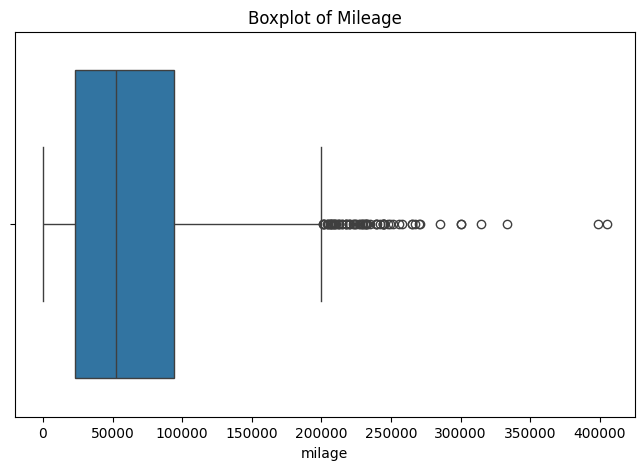

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['milage'])
plt.title("Boxplot of Mileage")
plt.show()

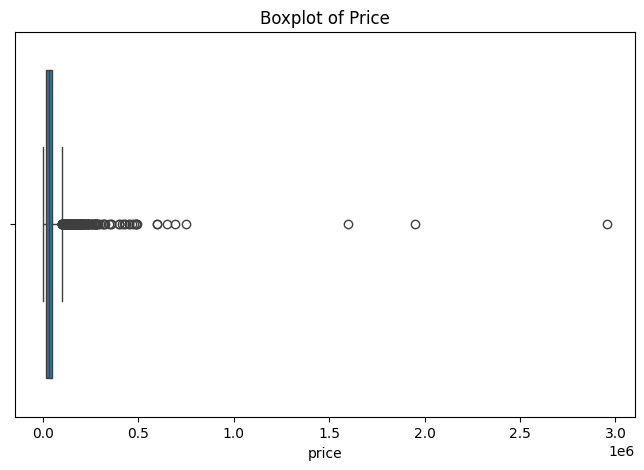

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['price'])
plt.title("Boxplot of Price")
plt.show()

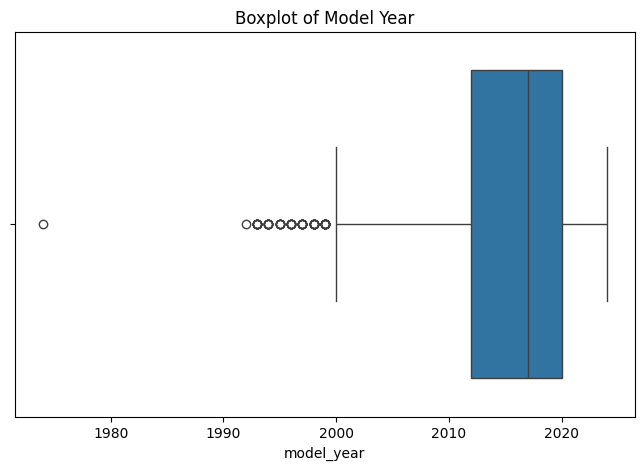

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['model_year'])
plt.title("Boxplot of Model Year")
plt.show()

In [59]:
Q1 = df_clean['milage'].quantile(0.25)
Q3 = df_clean['milage'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean['milage'] < lower) |
    (df_clean['milage'] > upper)
]

print("Mileage Outliers:", len(outliers))

Mileage Outliers: 69


In [60]:
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean['price'] < lower) |
    (df_clean['price'] > upper)
]

print("Price Outliers:", len(outliers))

Price Outliers: 244


In [61]:
current_year = 2025

df_clean['car_age'] = current_year - df_clean['model_year']

In [62]:
df_clean['mileage_per_year'] = (
    df_clean['milage'] /
    (df_clean['car_age'] + 1)
)

In [63]:
df_clean['price_per_mile'] = (
    df_clean['price'] /
    df_clean['milage']
)

In [64]:
df_clean['has_accident'] = (
    df_clean['accident']
    .eq('At least 1 accident or damage reported')
    .astype(int)
)

In [65]:
df_clean['is_automatic'] = (
    df_clean['transmission']
    .str.contains('Automatic|A/T', case=False, na=False)
    .astype(int)
)

In [66]:
df_clean.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,mileage_per_year,price_per_mile,has_accident,is_automatic
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,12,3923.076923,0.201961,1,1
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,4,6948.400000,1.093921,1,1
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,54598,3,5593.000000,2.440461,0,1
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,10,8081.818182,0.174353,0,1
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999,4,1967.000000,3.558617,0,1


In [67]:
df_clean.to_csv("cleaned_used_cars.csv", index=False)

In [68]:
from google.colab import files

files.download("cleaned_used_cars.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>